In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import seaborn as sns
import plotly as px

In [25]:
df = pd.read_excel(r"Products.xlsx")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower().str.replace(" ", "_")
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   name                               53 non-null     object
 1   state                              53 non-null     object
 2   location                           53 non-null     object
 3   land_holdings                      6 non-null      object
 4   owner                              53 non-null     object
 5   crops                              53 non-null     object
 6   landform_type                      42 non-null     object
 7   climatic_conditions                18 non-null     object
 8   innovation_and_practice_uses       52 non-null     object
 9   processing_type                    53 non-null     object
 10  result                             53 non-null     object
 11  profit_increase_or_revenue_growth  53 non-null     object
 12  employment

In [26]:
df=df.drop(columns=['land_holdings'])
df['crops']=df['crops'].str.lower()

In [27]:
df['processing_type'].value_counts()

processing_type
Products     23
Service      16
Processed    12
Raw           2
Name: count, dtype: int64

Text(0.5, 1.0, 'Processing of Produce')

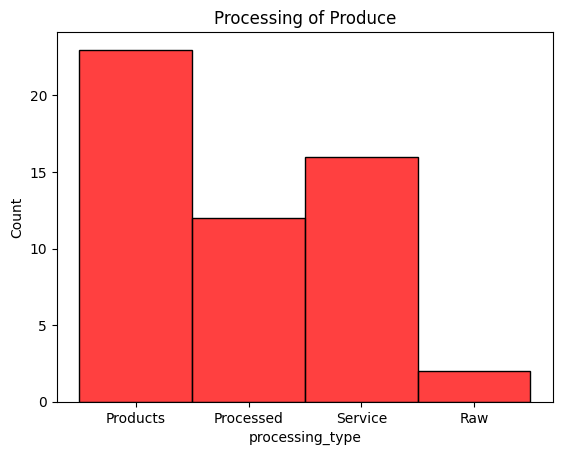

In [28]:
sns.histplot(data=df, x='processing_type', color='red')
plt.title("Processing of Produce")

employment_generation
Community Impact    19
Direct Jobs         19
Farmers served      15
Name: count, dtype: int64

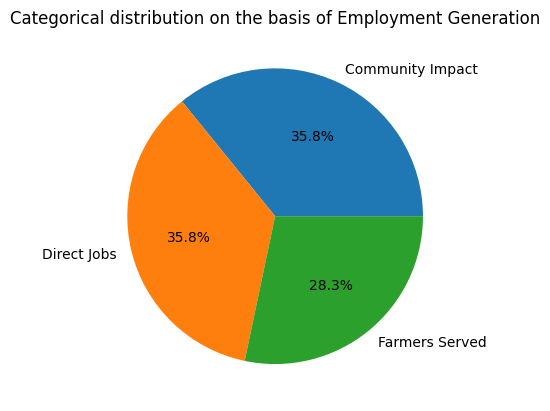

In [29]:
plt.pie(df['employment_generation'].value_counts(),labels=['Community Impact','Direct Jobs','Farmers Served'],autopct='%1.1f%%')
plt.title("Categorical distribution on the basis of Employment Generation")
df['employment_generation'].value_counts()

profit_increase_or_revenue_growth
Revenue Growth     33
Profit Increase    20
Name: count, dtype: int64

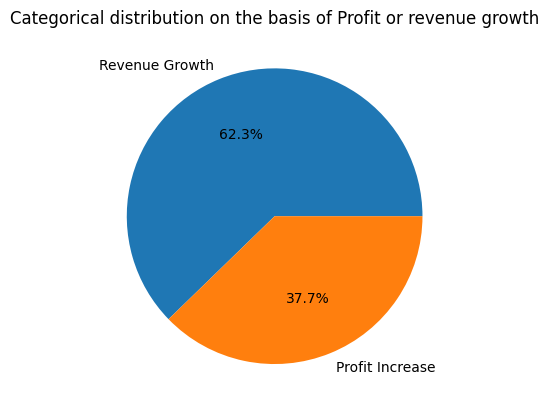

In [30]:
plt.pie(df['profit_increase_or_revenue_growth'].value_counts(),labels=['Revenue Growth','Profit Increase'],autopct='%1.1f%%')
plt.title("Categorical distribution on the basis of Profit or revenue growth")
df['profit_increase_or_revenue_growth'].value_counts()

Text(0.5, 1.0, 'Classification on the basis of Ownership')

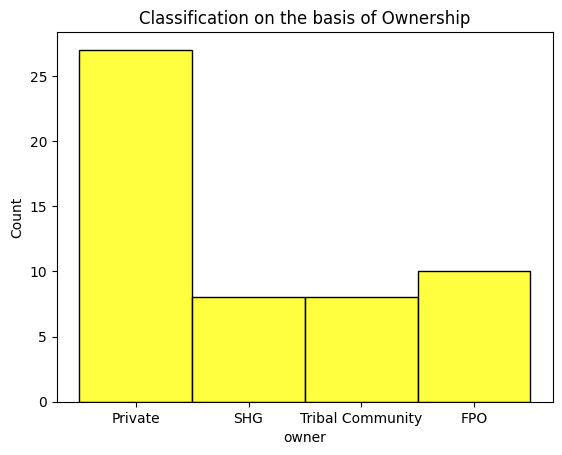

In [31]:
sns.histplot(data=df,x=df['owner'],color='yellow')
plt.title("Classification on the basis of Ownership")

<Axes: >

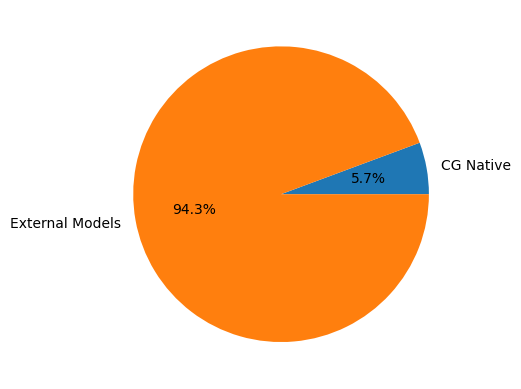

In [32]:
# Pie Chart - Native vs External Models
cg_native = df[df['state'] == 'Chhattisgarh']
external = df[df['state'] != 'Chhattisgarh']
pd.Series({'CG Native': len(cg_native), 'External Models': len(external)}).plot(kind='pie', autopct='%1.1f%%')

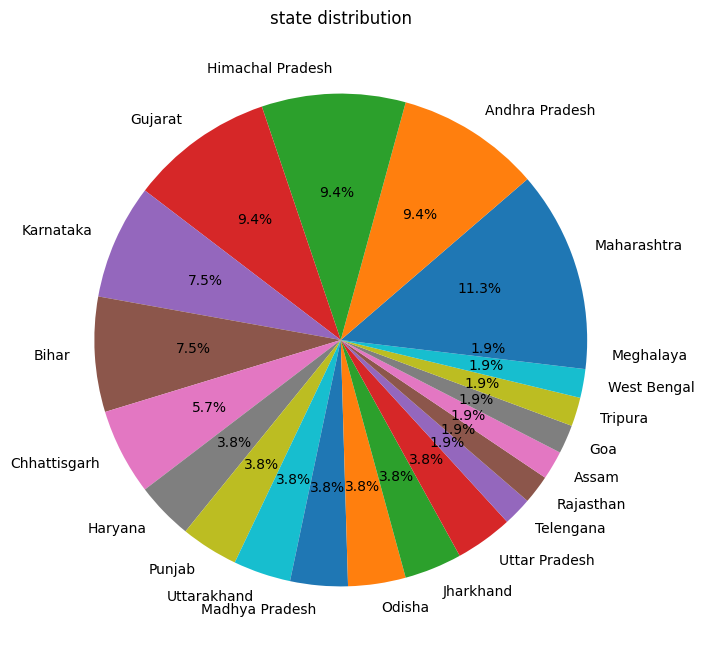

state
Maharashtra         6
Andhra Pradesh      5
Himachal Pradesh    5
Gujarat             5
Karnataka           4
Bihar               4
Chhattisgarh        3
Haryana             2
Punjab              2
Uttarakhand         2
Madhya Pradesh      2
Odisha              2
Jharkhand           2
Uttar Pradesh       2
Telengana           1
Rajasthan           1
Assam               1
Goa                 1
Tripura             1
West Bengal         1
Meghalaya           1
Name: count, dtype: int64

In [33]:
counts = df['state'].value_counts() 

plt.figure(figsize=(8,8))
plt.pie(
    counts.values,                # sizes
    labels=counts.index,          # labels auto detected
    autopct='%1.1f%%'
)

plt.title("state distribution")
plt.show()
df["state"].value_counts()

In [34]:
df[df['state']=='Chhattisgarh']

,name,state,location,owner,crops,landform_type,climatic_conditions,innovation_and_practice_uses,processing_type,result,profit_increase_or_revenue_growth,employment_generation,applicability_in_chhattisgarh,key_learning,remark
10,15 SHGs,Chhattisgarh,Durg,SHG,mushroom (oyster),Plains,NaN,Waste to Wealth:Using paddy straw for substrat...,Service,Income: Rs 20-25k/month.\n\nPrice: Rs 200-300/kg.,Profit Increase,Direct Jobs,NATIVE.\n\nproven model in Durg. Solves paddy ...,"Paddy straw is gold if used for mushrooms, not...","Low investment, high return."
11,Tribal FPO,Chhattisgarh,Rajnandgaon,FPO,tribal farming,Forest,NaN,"Agri-Mall: One-stop input shop.\n\nBrand: ""Chh...",Products,Inputs:Cheaper seeds/fertilizers.\n\nMiddlemen...,Revenue Growth,Farmers served,NATIVE.\n\nTribal FPOs can successfully run co...,Collective buying power lowers input costs sig...,Empowerment through ownership.
50,Millet Café (Raigarh SHG),Chhattisgarh,Raigarh,SHG,"ragi, kodo, and kutki (value added)",NaN,Tropical,Food Processing & Market Innovation: Establish...,Processed,Created direct self-employment for 10 women; e...,Revenue Growth,Community Impact,NATIVE. This is Chhattisgarh's flagship succes...,Value addition and modern presentation are the...,The success was driven by a strong collaborati...


### Forming Categories of the crops

In [35]:
product = []
for i in range(0,df.shape[0]):
    s = df.loc[i,'crops']
    s = s.replace("and",'')
    s = s.translate(str.maketrans('', '', string.punctuation))
    words = s.lower().split()
    product.extend(words)

In [36]:
product=list(set(product))
stopwords=['green','them','ifs','veggies','tribal','input','processing','bred','shop','the','dealer','red','master','postharvest','demo','integrated', 'clustermotivated', 'back','tissue','products','from','wild','added','shg','washing','box','powder','pits','agents','500','gir','daesi','buys','cattle', 'farmers','value','cleaning','to','organic','build','eri','finger']
product = [w for w in product if w not in stopwords]

In [37]:
crop_categories = {
    
    # Cereals & Millets
    "cereals_millets": [
        "millet", "jowar", "bajra", "foxtail",
        "ragi", "kodo", "kutki",
    ],
    
    # Pulses / Legumes
    "pulses": [
        "chickpea", "gram", "peas", "pulse", "pulses"
    ],
    
    # Fruits
    "fruits": [
        "mango", "banana", "papaya", "strawberry",
        "plum", "amla", "jackfruit", "tamarind"
    ],
    
    # Vegetables
    "vegetables": [
        "tomato", "brinjal", "cucumber", "ginger", "fennel"
    ],
    
    # Mushroom Farming
    "mushrooms": [
        "mushroom", "oyster"
    ],
    
    # Dairy & Livestock
    "dairy_livestock": [
        "dairy", "milk", "khoya", "paneer",
        "cows", "livestock", "fodder"
    ],
    
    # Beekeeping
    "beekeeping": [
        "honey", "beekeeping"
    ],
    
    # Plantation / Horticulture
    "horticulture": [
        "orchard", "flowers", "lemongrass"
    ],
    
    # Bamboo & Forest Products
    "bamboo_forest": [
        "bamboo", "crafts", "silk", "art"
    ],
    
    # Organic / Compost
    "organic_products": [
        "vermicompost", "compost"
    ],
    
    # Value Added / Processed
    "processed_products": [
        "jaggery", "sweets", "wadi"
    ],
    
    # Farming / Services
    "services": [
        "farming", "hydroponics", "tailoring",
        "trainer", "seed", "production","paddy"
    ]
}

def classify_crop_category(text):
    text = text.lower()  # normalize
    for key, keywords in crop_categories.items():
        for word in keywords:
            if word in text:
                return key
    return "Others"

df['crop_category'] = df['crops'].apply(classify_crop_category)

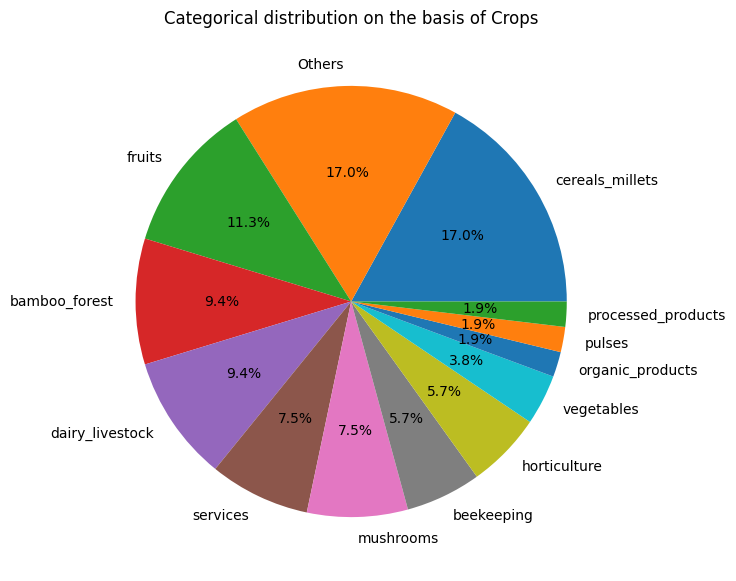

state
Maharashtra         6
Andhra Pradesh      5
Himachal Pradesh    5
Gujarat             5
Karnataka           4
Bihar               4
Chhattisgarh        3
Haryana             2
Punjab              2
Uttarakhand         2
Madhya Pradesh      2
Odisha              2
Jharkhand           2
Uttar Pradesh       2
Telengana           1
Rajasthan           1
Assam               1
Goa                 1
Tripura             1
West Bengal         1
Meghalaya           1
Name: count, dtype: int64

In [38]:
counts = df['crop_category'].value_counts() 

plt.figure(figsize=(7,7))
plt.pie(
    counts.values,                # sizes
    labels=counts.index,          # labels auto detected
    autopct='%1.1f%%'
)

plt.title("Categorical distribution on the basis of Crops")
plt.show()
df["state"].value_counts()

In [39]:
import plotly.express as px
import plotly.io as pio

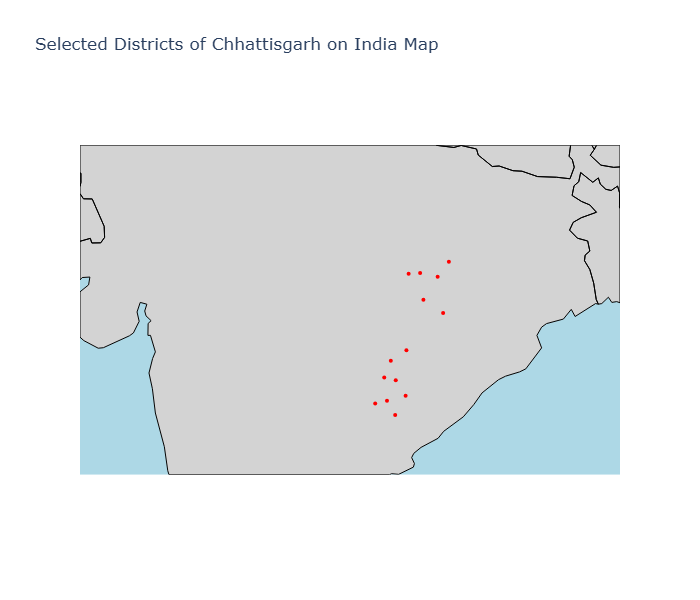

In [40]:
# District data
data = {
    "District": [
        "Bastar (Jagdalpur)", "Dantewada", "Bijapur", "Narayanpur",
        "Kondagaon", "Sukma", "Kanker", "Surguja",
        "Balrampur", "Surajpur", "Koriya", "Korba",
        "Raigarh", "Gariyaband"
    ],
    "Latitude": [
        19.07, 18.90, 18.80, 19.70,
        19.60, 18.40, 20.27, 23.12,
        23.62, 23.22, 23.25, 22.35,
        21.90, 20.63
    ],
    "Longitude": [
        82.03, 81.35, 80.92, 81.25,
        81.67, 81.65, 81.49, 83.20,
        83.61, 82.14, 82.56, 82.68,
        83.40, 82.06
    ]
}

df1 = pd.DataFrame(data)

# Plot on India map
fig = px.scatter_geo(
    df1,
    lat="Latitude",
    lon="Longitude",
    hover_name="District",
    title="Selected Districts of Chhattisgarh on India Map"
)

# Set map to India
fig.update_geos(
    scope="asia",              # shows India clearly
    showcountries=True,
    countrycolor="black",
    showsubunits=True,
    subunitcolor="gray",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    center={"lat": 22, "lon": 80},   # center near India
    projection_scale=7               # zoom level
)

fig.update_traces(marker=dict(size=4, color="red"))

fig.update_layout(height=600)

fig.show()
fig.write_image("map.png")

# Display PNG in notebook
from IPython.display import Image
Image("map.png")

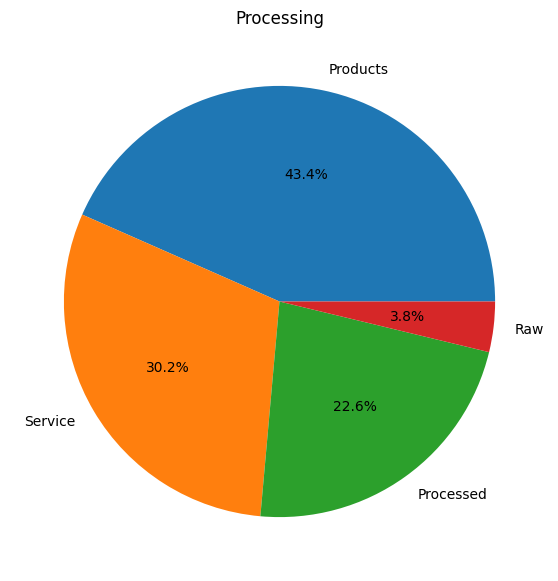

In [41]:
counts = df['processing_type'].value_counts() 

plt.figure(figsize=(7,7))
plt.pie(
    counts.values,                # sizes
    labels=counts.index,          # labels auto detected
    autopct='%1.1f%%'
)

plt.title("Processing")
plt.show()

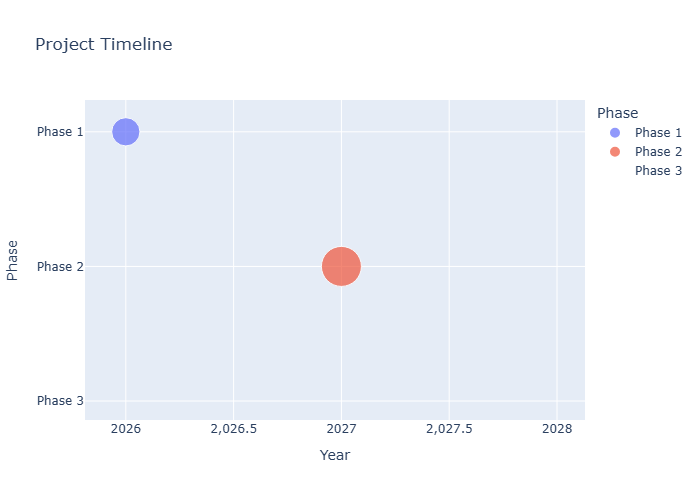

In [42]:
import pandas as pd
import plotly.express as px

# Timeline data
d = pd.DataFrame({
    "Phase": ["Phase 1", "Phase 2", "Phase 3"],
    "Year": [2026, 2027, 2028],
    "Funding (Cr)": [100, 200, 0],
    "Details": [
        "SHG Processing Hubs\n• Mushroom model\n• Mini dal mills",
        "FSSAI + Cold Storage\n• Mango/Cashew\n• Cafe franchises",
        "NGO Training Program"
    ]
})

# Timeline plot
fig = px.scatter(
    d,
    x="Year",
    y="Phase",
    size="Funding (Cr)",
    color="Phase",
    hover_data=["Details"],
    title="Project Timeline"
)

fig.update_traces(marker=dict(sizemode='area', sizeref=2.*max(d["Funding (Cr)"])/(40.**2)))

fig.show()
fig.write_image("plot.png")

# Display PNG in notebook
from IPython.display import Image
Image("plot.png")

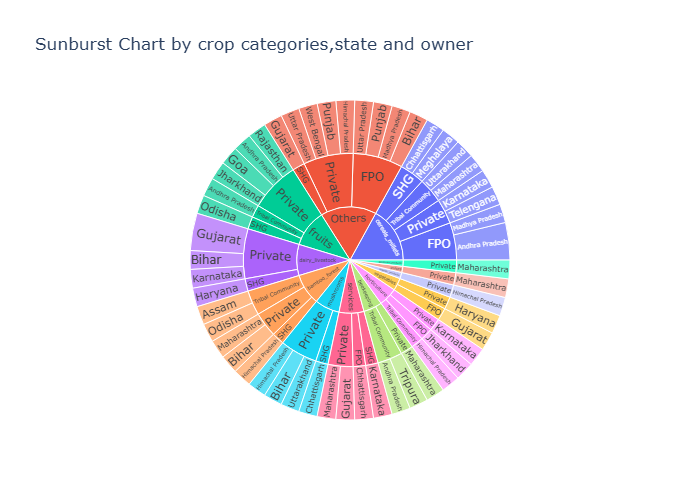

In [43]:
fig = px.sunburst(
    df,
    path=["crop_category", "owner", "state"],
    title="Sunburst Chart by crop categories,state and owner",
    width=700,
    height=500
)
fig.show()
fig.write_image("sun_burst.png")

# Display PNG in notebook
from IPython.display import Image
Image("sun_burst.png")

In [44]:
df.to_excel("products_cleaned.xlsx", index=False)